precise expression curves

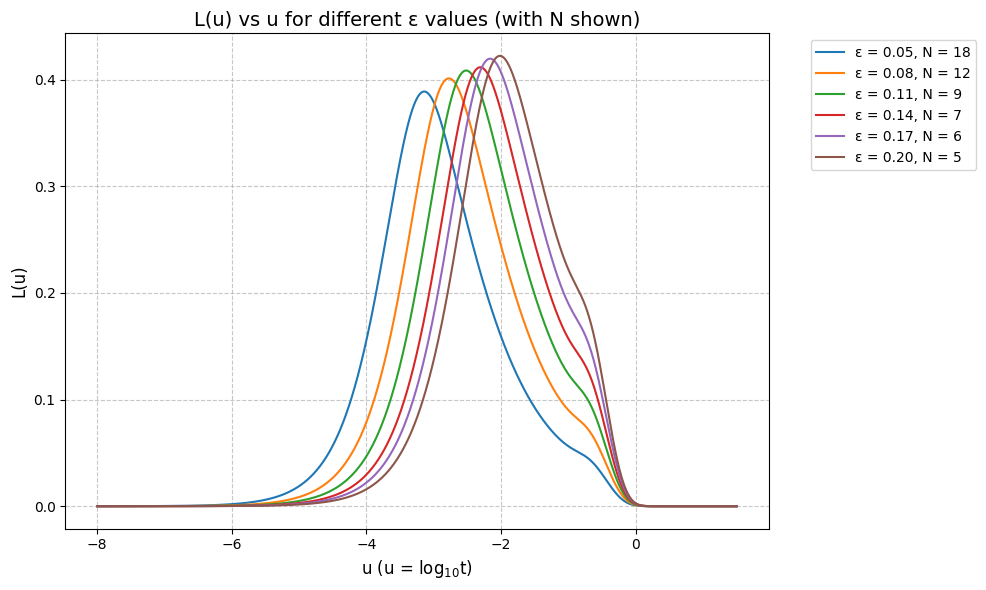

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1, jn_zeros
import matplotlib.colors as mcolors
import math

# Parameter settings
a = 0.9
D = 1.005
epsilon_values = np.arange(0.05,0.22,0.03)  # ε from 0.05 to 0.9 with 0.05 step
t = np.logspace(-8, 1.5, 2000)  # t values (logarithmic scale from 10^-3 to 10^0)
u = np.log10(t)  # u = log10(t)
ln10 = np.log(10)  # Natural logarithm of 10

# Create color list
colors = list(mcolors.TABLEAU_COLORS.values())
color_cycle = [colors[i % len(colors)] for i in range(len(epsilon_values))]

# Plot the figure
plt.figure(figsize=(10, 6))

for idx, epsilon in enumerate(epsilon_values):
    # Avoid division by zero
    if abs(2*a - epsilon) < 1e-10:
        continue

    # Calculate number of series terms N, ensuring N is at least 5
    N = math.ceil(a / epsilon)
    N = max(N, 5)  # Ensure minimum 5 terms

    # Get first N zeros of Bessel function J0
    alpha_0_n = jn_zeros(0, N)

    L_t = np.zeros_like(t)
    factor = 4 * D / (epsilon * (2*a - epsilon))

    for n in range(N):
        alpha = alpha_0_n[n]
        # Calculate Bessel function value
        j1_alpha = j1(alpha)
        if abs(j1_alpha) < 1e-10:  # Avoid division by zero
            continue

        # Calculate exponential term
        exp_term = np.exp(-(alpha**2 * D * t) / (a**2))

        # Calculate terms inside the bracket
        term1 = j1_alpha
        factor2 = 1 - epsilon / a
        term2 = factor2 * j1(alpha * factor2)
        bracket_term = term1 - term2

        # Accumulate series terms
        L_t += (1 / j1_alpha) * exp_term * bracket_term

    # Apply the coefficient to get L(t)
    L_t *= factor

    # Calculate L(u) = t * ln10 * L(t)
    L_u = t * ln10 * L_t

    # Plot the curve with N value in legend
    plt.plot(u, L_u, label=f'ε = {epsilon:.2f}, N = {N}',
             color=color_cycle[idx], linewidth=1.5)

# Figure settings
plt.xlabel(r'u (u = log$_{10}$t)', fontsize=12)
plt.ylabel('L(u)', fontsize=12)
plt.title('L(u) vs u for different ε values (with N shown)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()


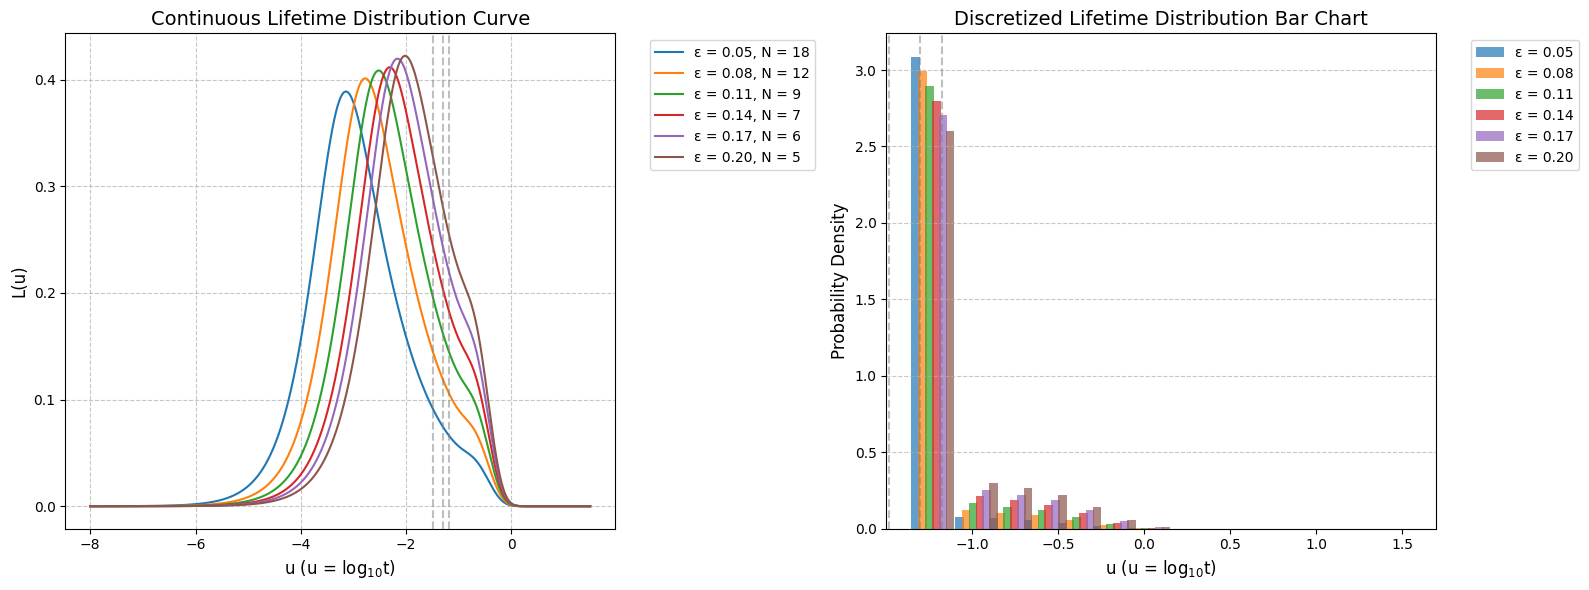

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1, jn_zeros
import matplotlib.colors as mcolors
import math

# Parameter settings
a = 0.9
D = 1.005
epsilon_values = np.arange(0.05, 0.22, 0.03)  # Range of ε values
t = np.logspace(-8, 1.5, 2000)  # Time values (logarithmic scale)
u = np.log10(t)  # u = log10(t)
ln10 = np.log(10)  # Natural logarithm of 10

# Time interval definitions (units: seconds)
ms33 = 0.033  # 33 milliseconds
ms50 = 0.050  # 50 milliseconds
ms67 = 0.067  # 67 milliseconds
log33 = np.log10(ms33)
log50 = np.log10(ms50)
log67 = np.log10(ms67)
peak_position = 0.5 * (log33 + log67)  # Primary peak position log10(0.047)

# Create color list
colors = list(mcolors.TABLEAU_COLORS.values())
color_cycle = [colors[i % len(colors)] for i in range(len(epsilon_values))]

# Define log bins for long lifetime intervals
log_bins = np.arange(log67, 1.6, 0.2)  # Bins starting from log10(0.067)
all_bin_centers = [peak_position] + [(log_bins[i] + log_bins[i+1])/2 for i in range(len(log_bins)-1)]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for idx, epsilon in enumerate(epsilon_values):
    # Avoid division by zero
    if abs(2*a - epsilon) < 1e-10:
        continue

    # Calculate number of series terms N, ensuring minimum 5
    N = math.ceil(a / epsilon)
    N = max(N, 5)  # Ensure at least 5 terms

    # Get first N zeros of Bessel function J0
    alpha_0_n = jn_zeros(0, N)

    L_t = np.zeros_like(t)
    factor = 4 * D / (epsilon * (2*a - epsilon))

    for n in range(N):
        alpha = alpha_0_n[n]
        # Calculate Bessel function value
        j1_alpha = j1(alpha)
        if abs(j1_alpha) < 1e-10:  # Avoid division by zero
            continue

        # Calculate exponential term
        exp_term = np.exp(-(alpha**2 * D * t) / (a**2))

        # Calculate terms inside the bracket
        term1 = j1_alpha
        factor2 = 1 - epsilon / a
        term2 = factor2 * j1(alpha * factor2)
        bracket_term = term1 - term2

        # Accumulate series terms
        L_t += (1 / j1_alpha) * exp_term * bracket_term

    # Apply coefficient to get L(t)
    L_t *= factor

    # Calculate L(u) = t * ln10 * L(t)
    L_u = t * ln10 * L_t

    # Original continuous curve
    ax1.plot(u, L_u, label=f'ε = {epsilon:.2f}, N = {N}',
             color=color_cycle[idx], linewidth=1.5)

    # --------------------------
    # Discretization operation
    # --------------------------

    # 1. Separate into parts less than 50ms and greater than 50ms
    mask_less50 = t < ms50  # Part less than 50ms
    mask_more50 = t >= ms50  # Part greater than or equal to 50ms

    # 2. Calculate cumulative probability for lifetimes less than 50ms (linearly binned)
    # Use numerical integration to calculate cumulative probability
    delta_t = np.diff(t)
    # Ensure delta_t has the same length as t
    delta_t = np.concatenate([delta_t, [delta_t[-1]]])
    cumulative_less50 = np.sum(L_t[mask_less50] * delta_t[mask_less50])

    # 3. Convert to log-binned probability density at primary peak
    log_width = np.log10(ms67) - np.log10(ms33)  # log10(2)
    peak_density = cumulative_less50 / log_width

    # 4. Process part greater than 50ms, calculate probability density for each log bin
    bin_densities = []
    for i in range(len(log_bins)-1):
        bin_start = log_bins[i]
        bin_end = log_bins[i+1]
        # Find data points within current log bin
        mask_bin = (u >= bin_start) & (u < bin_end) & mask_more50

        if np.any(mask_bin):
            # Calculate average probability density for this bin
            bin_density = np.mean(L_u[mask_bin])
            bin_densities.append(bin_density)
        else:
            bin_densities.append(0)

    # 5. Normalization processing
    # Calculate integral of continuous part
    continuous_integral = 0
    for i in range(len(log_bins)-1):
        bin_width = log_bins[i+1] - log_bins[i]
        continuous_integral += bin_densities[i] * bin_width

    # Total probability
    total_prob = peak_density * log_width + continuous_integral

    # Normalize
    peak_density_normalized = peak_density / total_prob
    bin_densities_normalized = [d / total_prob for d in bin_densities]

    # Plot bar chart
    all_densities = [peak_density_normalized] + bin_densities_normalized
    bar_width = 0.05  # Bar width

    # Offset each epsilon value slightly to avoid complete overlap
    offsets = np.zeros_like(all_densities) + idx * bar_width * 0.8

    ax2.bar(np.array(all_bin_centers) + offsets, all_densities,
            width=bar_width, color=color_cycle[idx], alpha=0.7,
            label=f'ε = {epsilon:.2f}')

# Continuous curve plot settings
ax1.set_xlabel(r'u (u = log$_{10}$t)', fontsize=12)
ax1.set_ylabel('L(u)', fontsize=12)
ax1.set_title('Continuous Lifetime Distribution Curve', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=log33, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=log50, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=log67, color='gray', linestyle='--', alpha=0.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

# Bar chart settings
ax2.set_xlabel(r'u (u = log$_{10}$t)', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('Discretized Lifetime Distribution Bar Chart', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7, axis='y')
ax2.axvline(x=log33, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=log50, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=log67, color='gray', linestyle='--', alpha=0.5)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

plt.tight_layout()
plt.show()


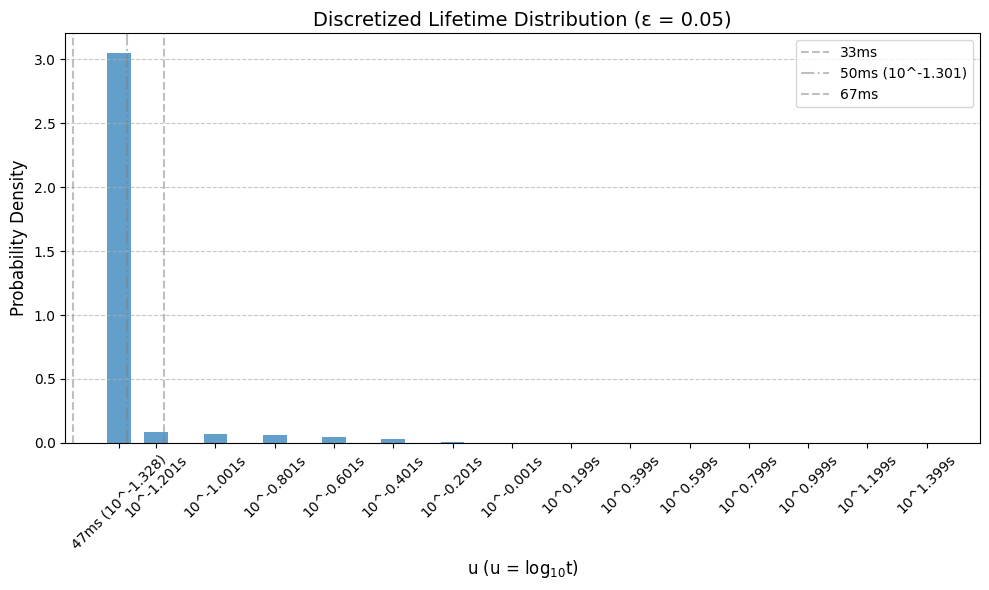

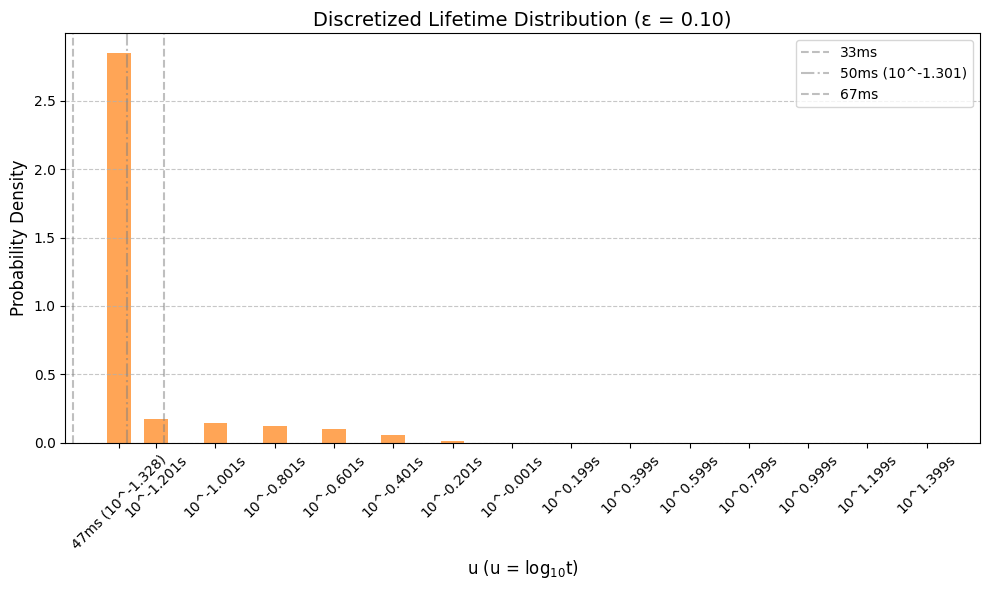

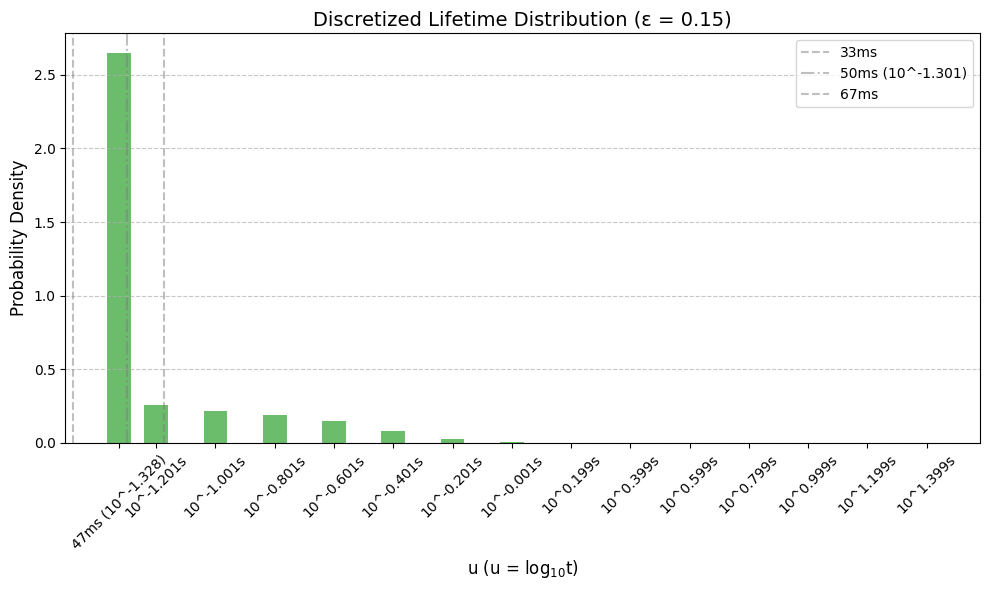

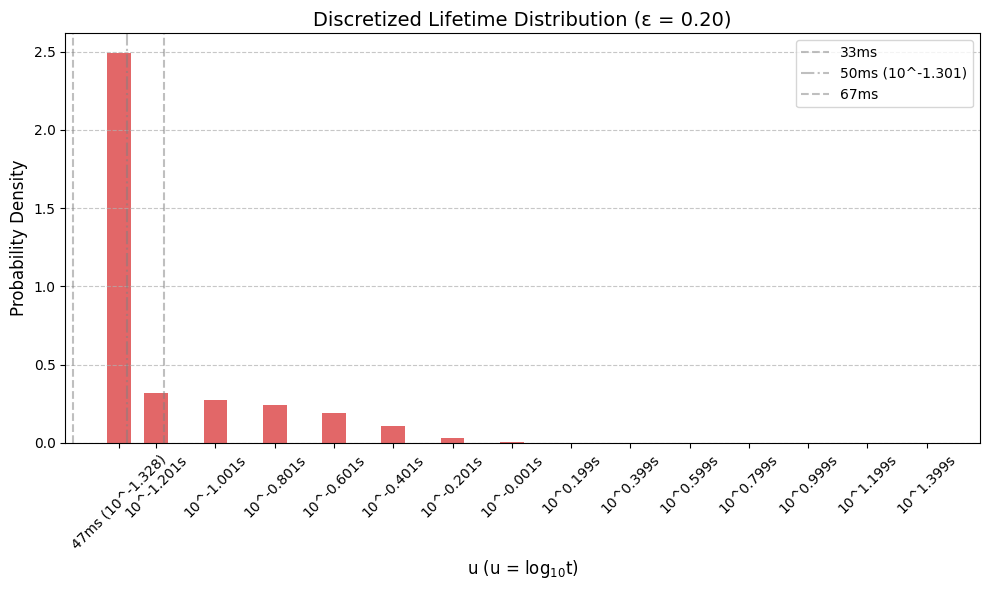

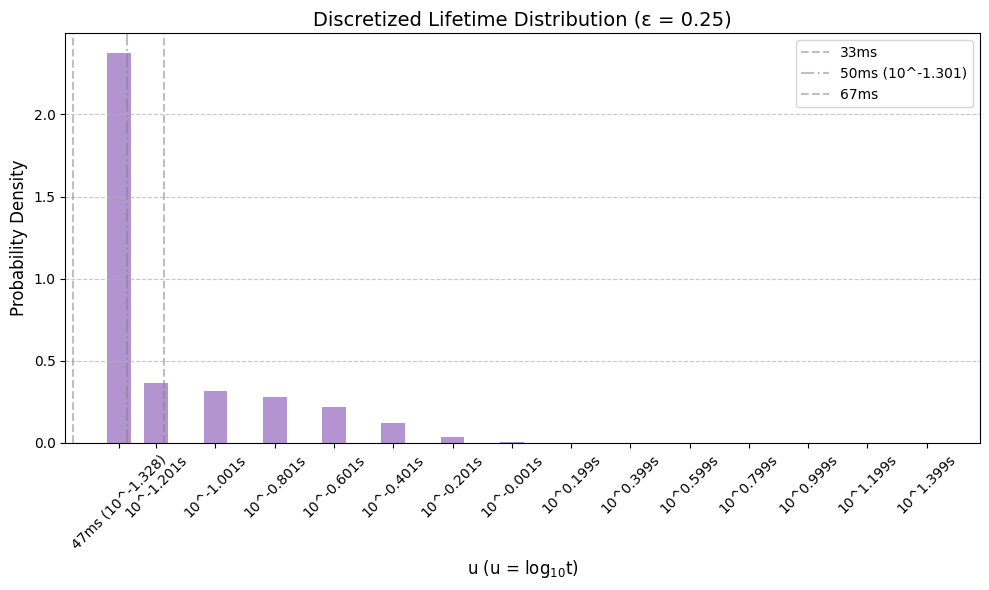

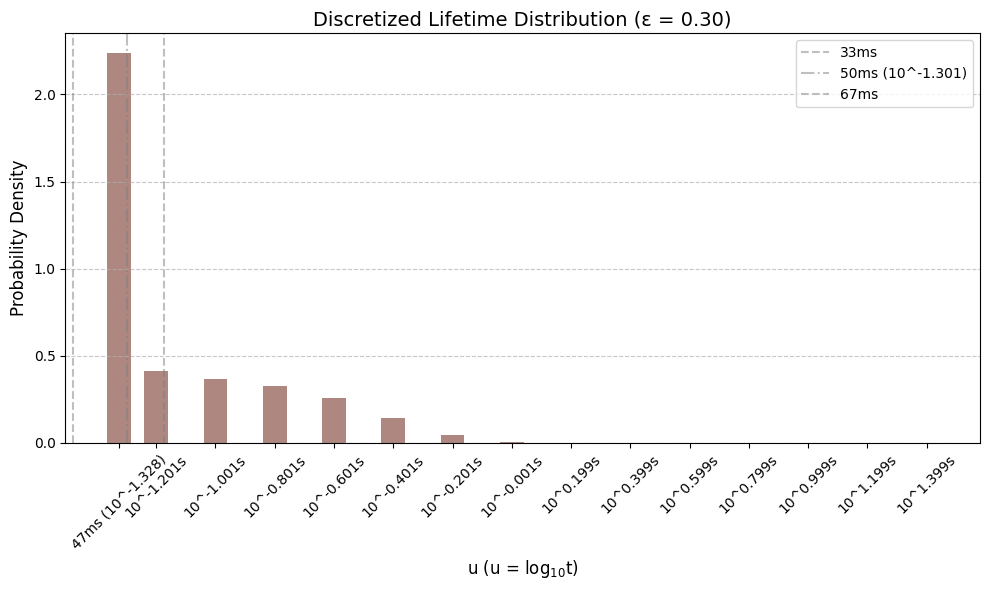

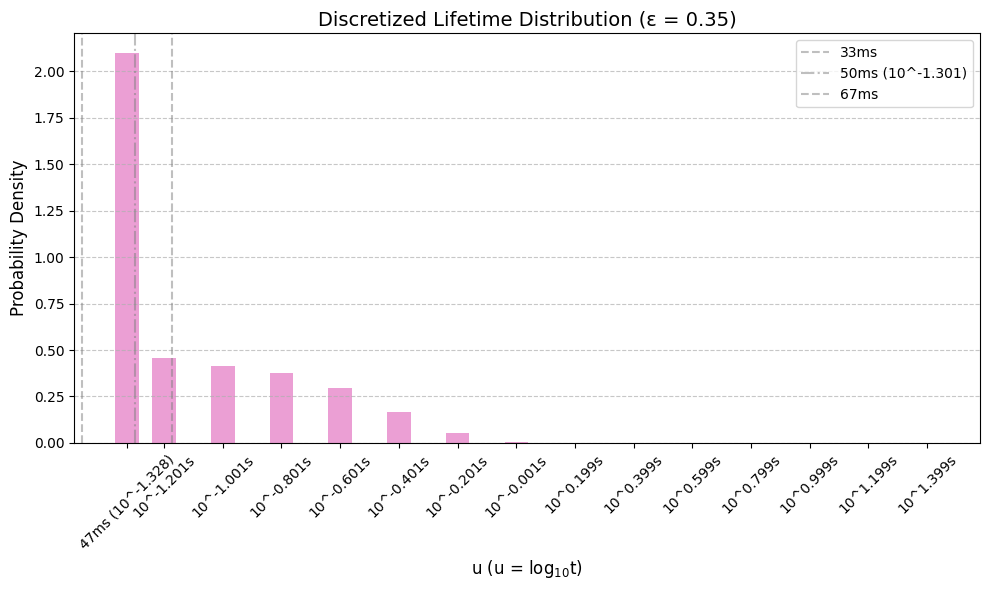

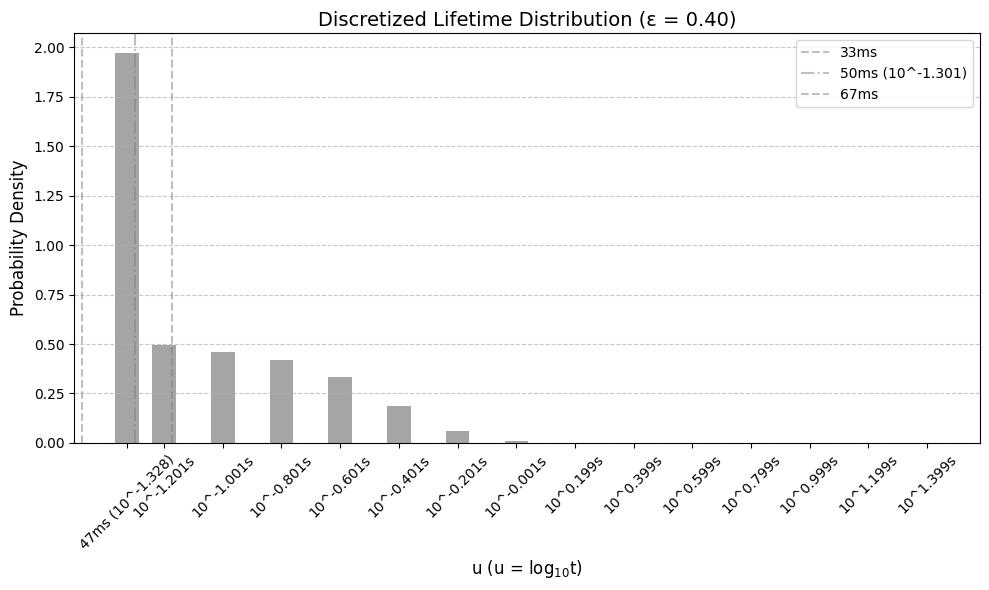

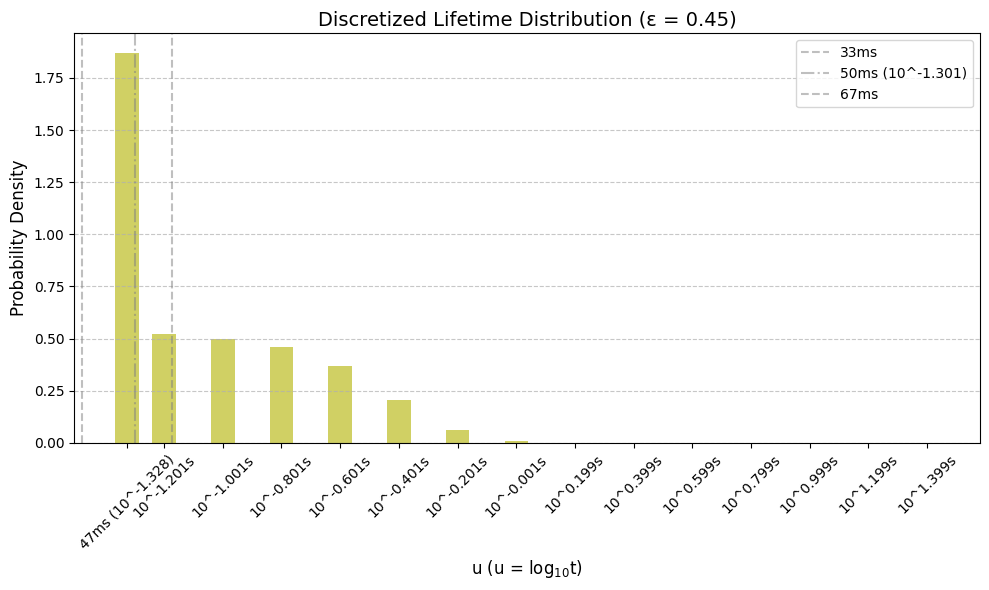

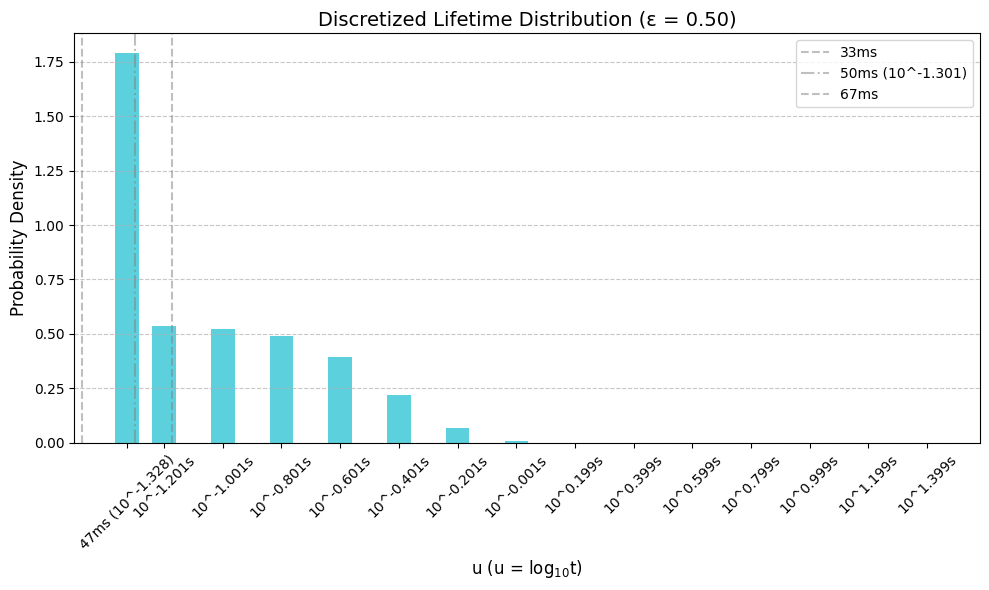

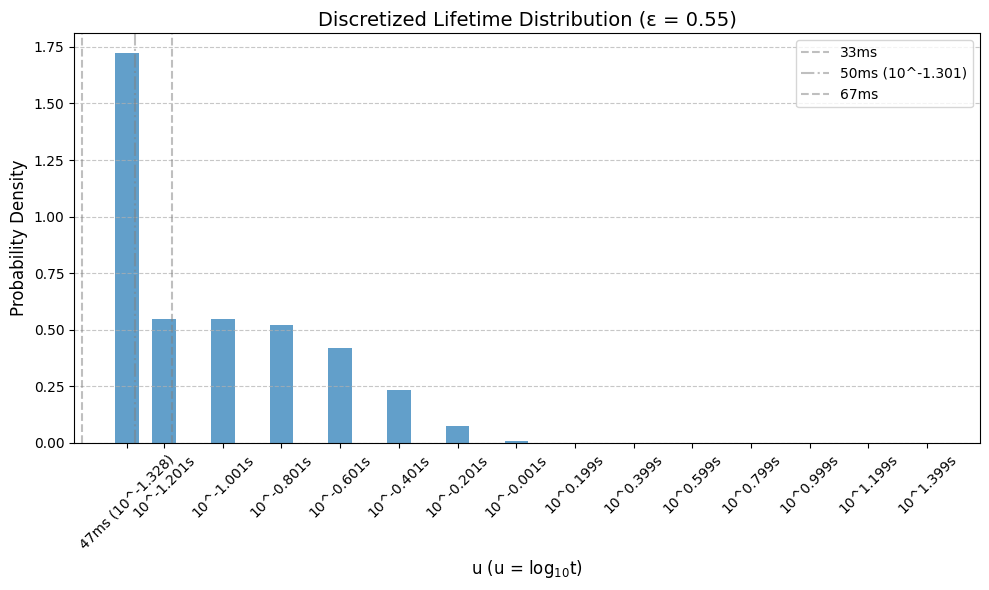

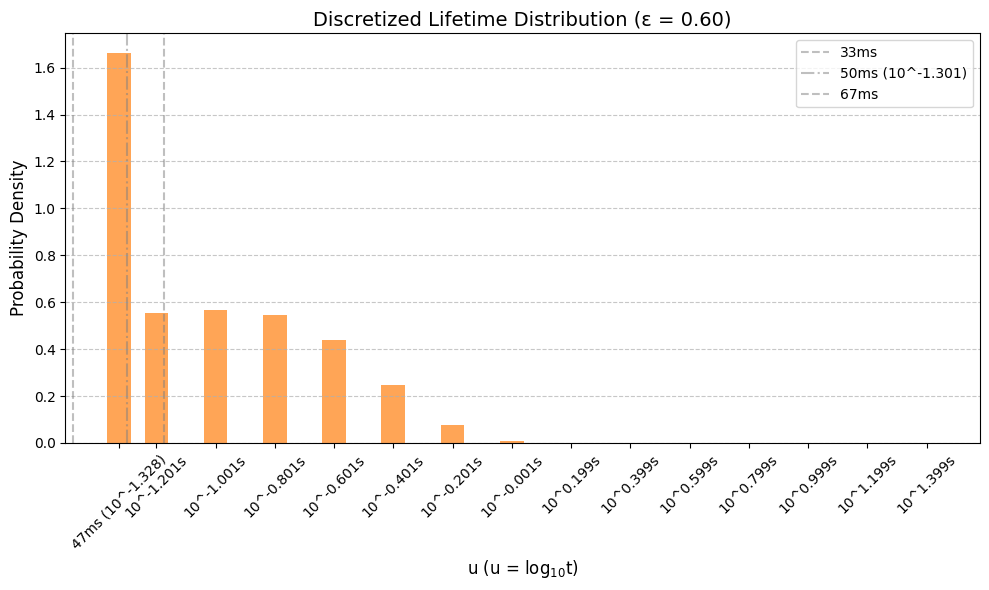

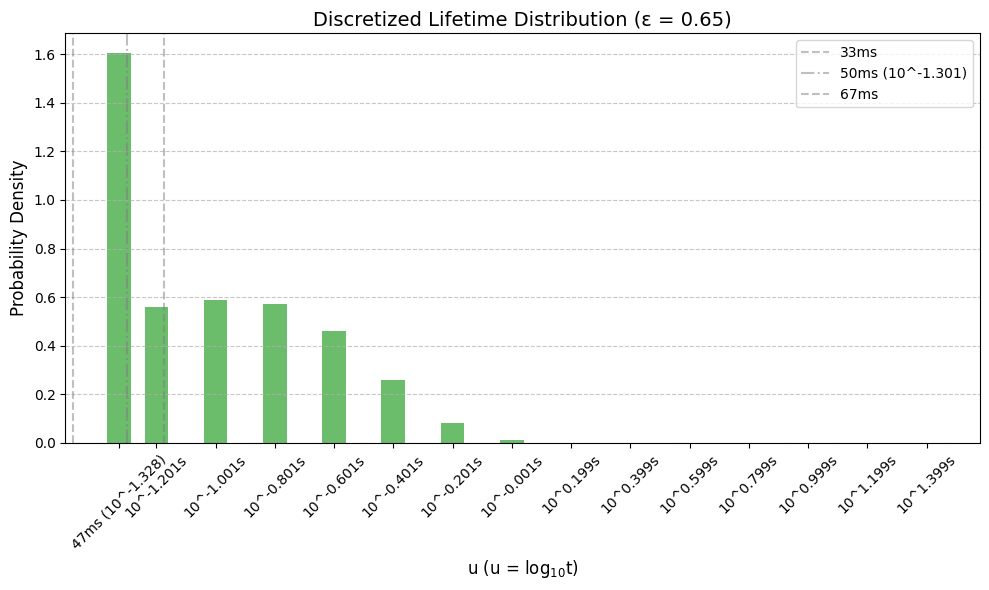

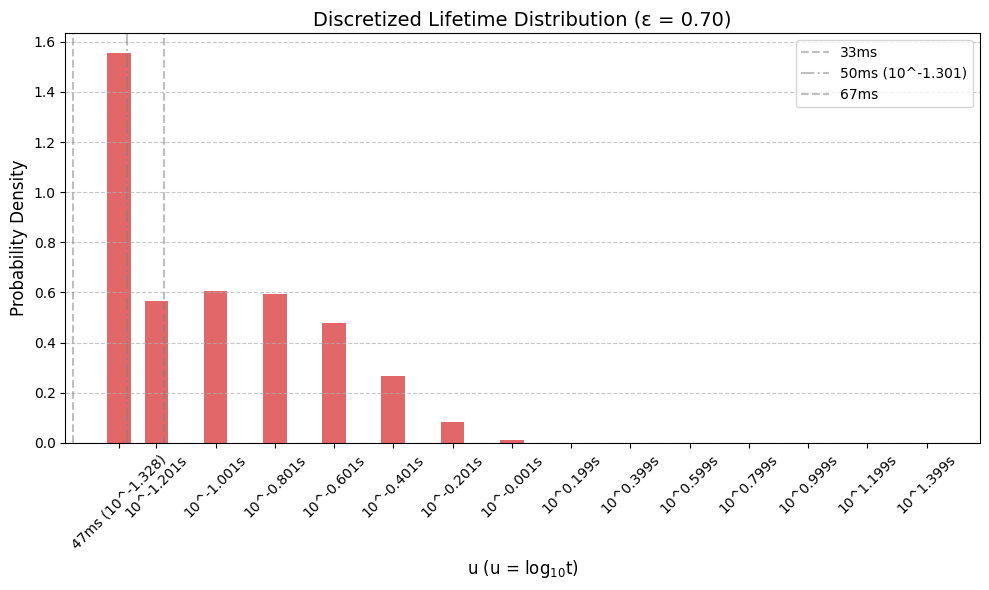

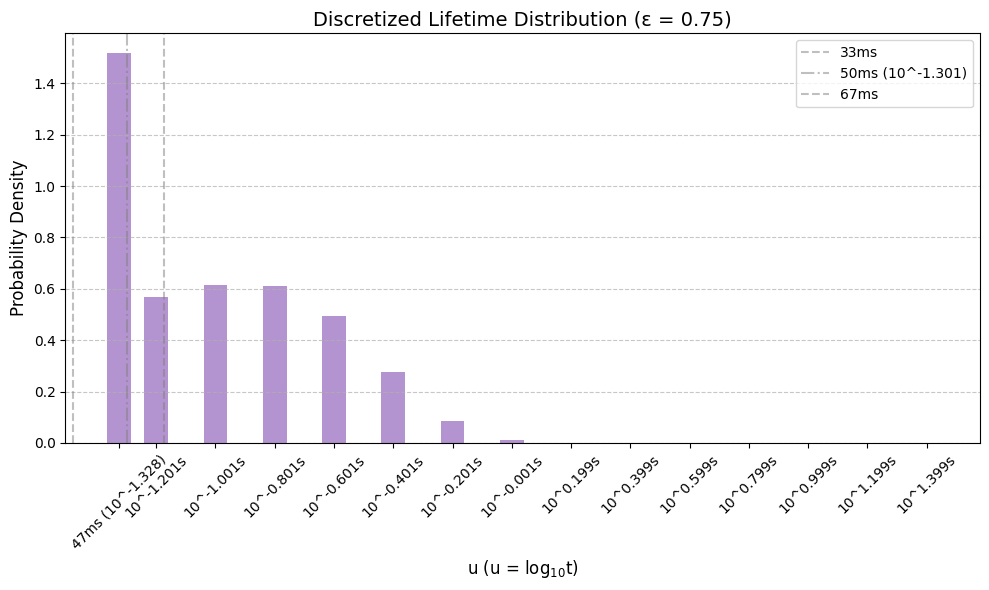

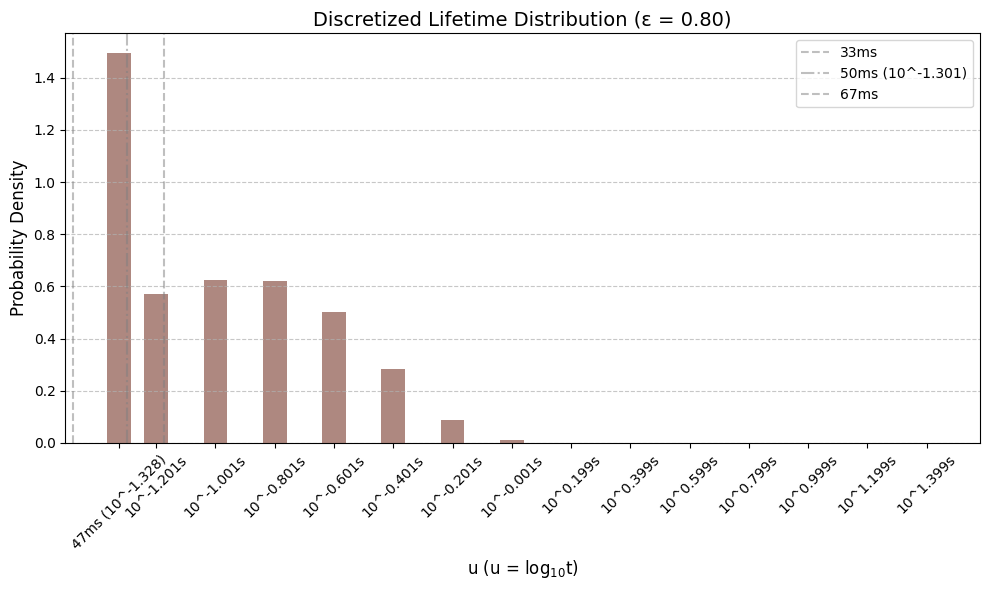

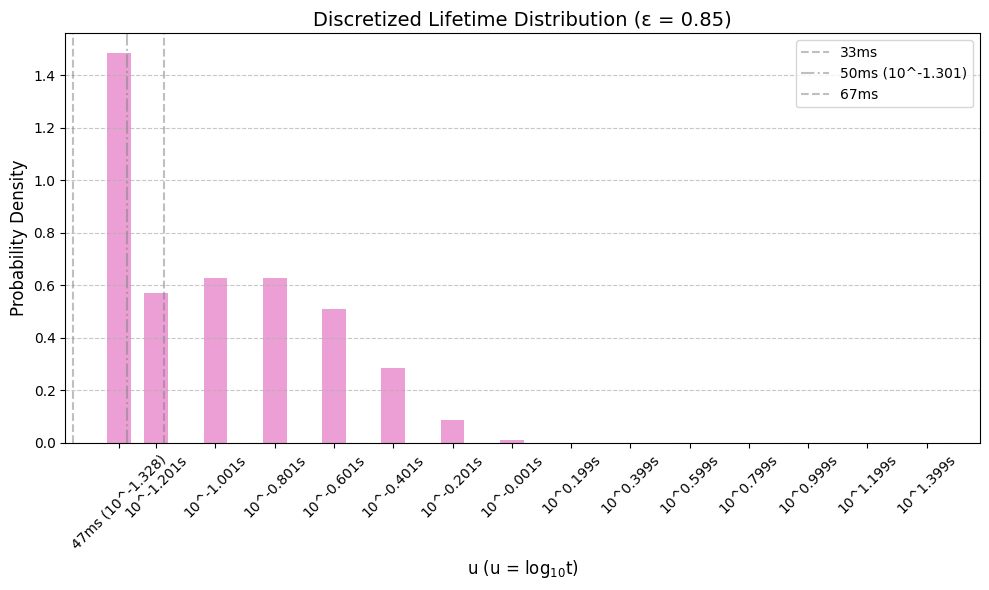

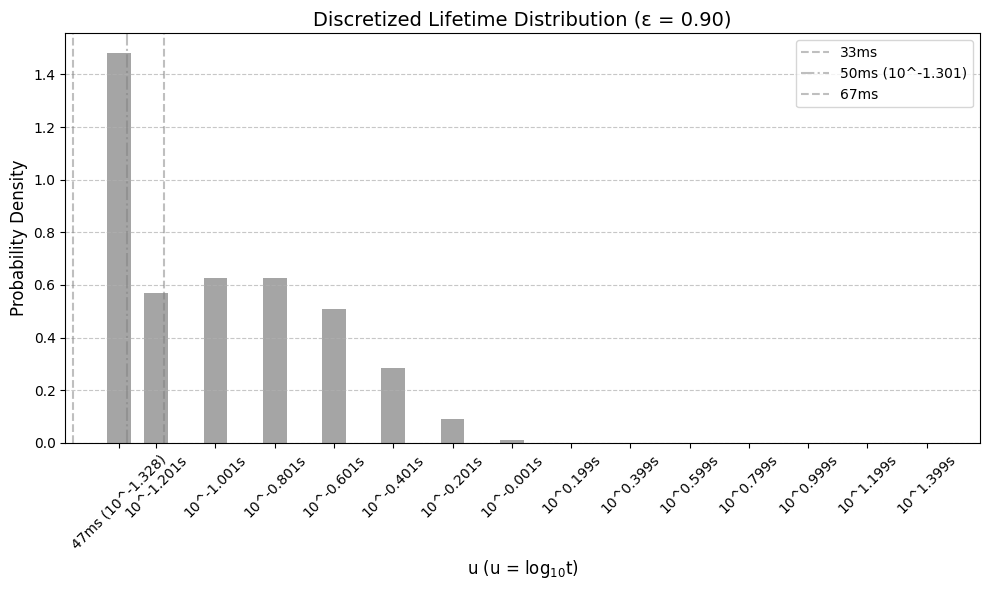

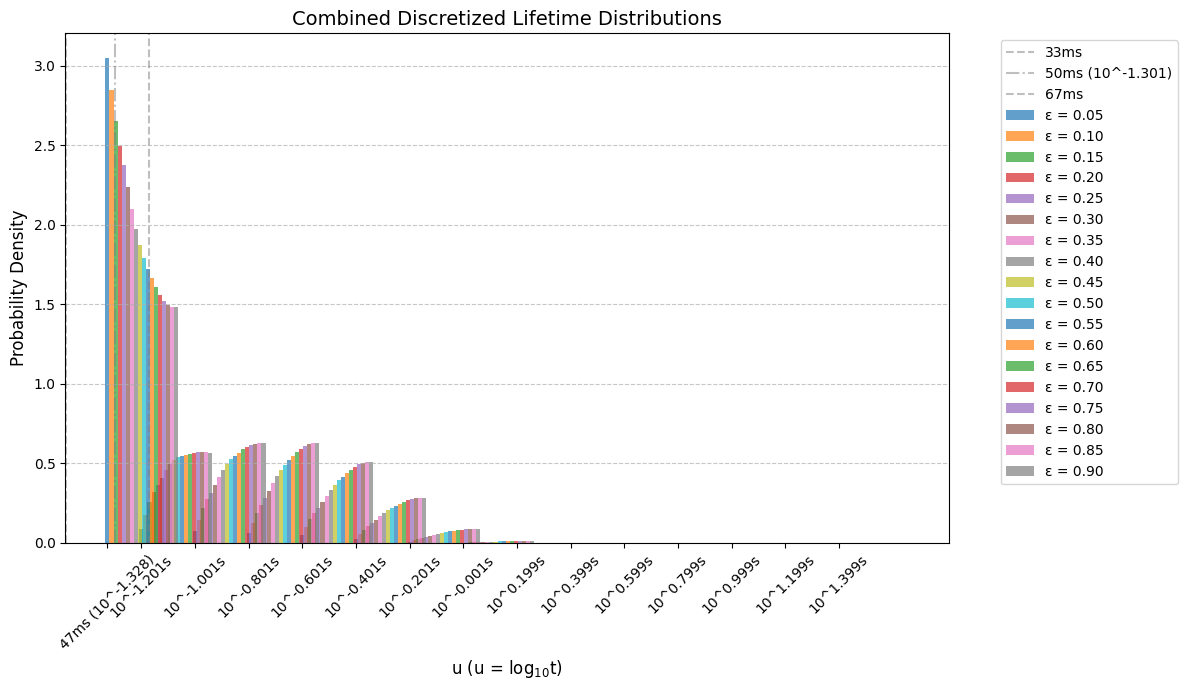

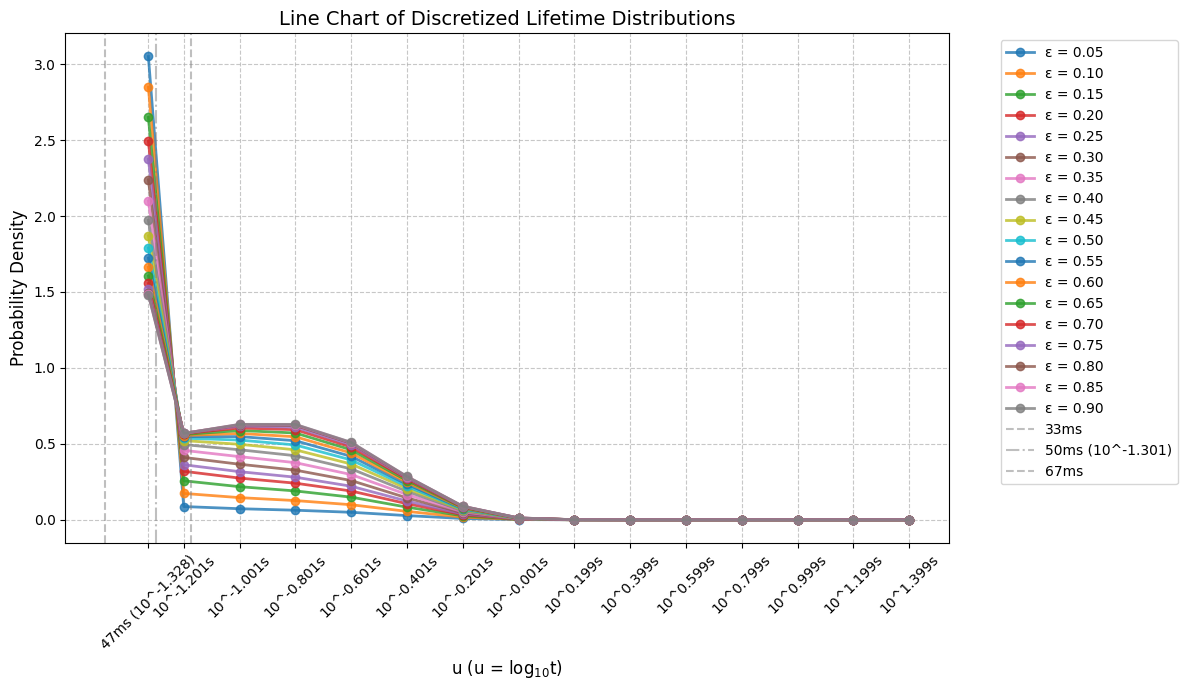

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1, jn_zeros
import matplotlib.colors as mcolors
import math
from matplotlib.ticker import ScalarFormatter

# Parameter settings
a = 0.9
D = 1.005
# 扩展epsilon值范围到1附近
epsilon_values = np.arange(0.05, 0.95, 0.05)  # 从0.05到1.0，步长0.05
t = np.logspace(-8, 1.5, 2000)  # Time values (logarithmic scale)
u = np.log10(t)  # u = log10(t)
ln10 = np.log(10)  # Natural logarithm of 10

# Time interval definitions (units: seconds)
ms33 = 0.033  # 33 milliseconds
ms50 = 0.050  # 50 milliseconds
ms67 = 0.067  # 67 milliseconds
log33 = np.log10(ms33)
log50 = np.log10(ms50)  # 10^-1.301 s
log67 = np.log10(ms67)
peak_position = 0.5 * (log33 + log67)  # Primary peak position at ~47ms (10^-1.33 s)

# Create color list
colors = list(mcolors.TABLEAU_COLORS.values())
color_cycle = [colors[i % len(colors)] for i in range(len(epsilon_values))]

# 调整log bins：从log50(50ms)开始，使用0.2的对数间隔
# 第一个连续分箱范围：10^-1.301到10^-1.101，中点在10^-1.201
log_bins = np.arange(log50, 1.6, 0.2)  # 从log50开始，步长0.2

# 计算分箱中心
all_bin_centers = [peak_position]  # 首先添加峰值点
for i in range(len(log_bins)-1):
    # 每个分箱的中心是起点和终点的平均值
    bin_center = (log_bins[i] + log_bins[i+1]) / 2
    all_bin_centers.append(bin_center)

# 创建分箱标签，更清晰地显示第一个连续分箱
bin_labels = [f'47ms (10^{peak_position:.3f})']
for b in all_bin_centers[1:]:
    # 特别标记第一个连续分箱
    if i == 0:
        bin_labels.append(f'10^{b:.3f}s (50-79ms)')
    else:
        bin_labels.append(f'10^{b:.3f}s')

# Store results for combined plots
all_results = []

# Calculate distributions for all epsilon values
for idx, epsilon in enumerate(epsilon_values):
    # 避免除以零
    if abs(2*a - epsilon) < 1e-10:
        continue

    # 计算级数项数量N，确保至少5项
    N = math.ceil(a / epsilon)
    N = max(N, 5)  # 确保至少5项

    # 获取贝塞尔函数J0的前N个零点
    alpha_0_n = jn_zeros(0, N)

    L_t = np.zeros_like(t)
    factor = 4 * D / (epsilon * (2*a - epsilon))

    for n in range(N):
        alpha = alpha_0_n[n]
        # 计算贝塞尔函数值
        j1_alpha = j1(alpha)
        if abs(j1_alpha) < 1e-10:  # 避免除以零
            continue

        # 计算指数项
        exp_term = np.exp(-(alpha**2 * D * t) / (a**2))

        # 计算括号内的项
        term1 = j1_alpha
        factor2 = 1 - epsilon / a
        term2 = factor2 * j1(alpha * factor2)
        bracket_term = term1 - term2

        # 累积级数项
        L_t += (1 / j1_alpha) * exp_term * bracket_term

    # 应用系数得到L(t)
    L_t *= factor

    # 计算L(u) = t * ln10 * L(t)
    L_u = t * ln10 * L_t

    # --------------------------
    # 离散化操作
    # --------------------------

    # 1. 分为小于50ms和大于等于50ms的部分
    mask_less50 = t < ms50  # 小于50ms的部分
    mask_more50 = t >= ms50  # 大于等于50ms的部分

    # 2. 计算小于50ms寿命的累积概率（线性分箱）
    delta_t = np.diff(t)
    delta_t = np.concatenate([delta_t, [delta_t[-1]]])
    cumulative_less50 = np.sum(L_t[mask_less50] * delta_t[mask_less50])

    # 3. 转换为主要峰值处的对数分箱概率密度
    log_width = np.log10(ms67) - np.log10(ms33)  # log10(2)
    peak_density = cumulative_less50 / log_width

    # 4. 处理大于50ms的部分，计算每个对数分箱的密度
    bin_densities = []
    for i in range(len(log_bins)-1):
        bin_start = log_bins[i]
        bin_end = log_bins[i+1]
        # 筛选当前分箱且大于等于50ms的数据
        mask_bin = (u >= bin_start) & (u < bin_end) & mask_more50

        if np.any(mask_bin):
            bin_density = np.mean(L_u[mask_bin])
            bin_densities.append(bin_density)
        else:
            bin_densities.append(0)

    # 5. 归一化处理
    continuous_integral = 0
    for i in range(len(log_bins)-1):
        bin_width = log_bins[i+1] - log_bins[i]
        continuous_integral += bin_densities[i] * bin_width

    total_prob = peak_density * log_width + continuous_integral

    # 归一化
    if total_prob > 0:  # 避免除以零
        peak_density_normalized = peak_density / total_prob
        bin_densities_normalized = [d / total_prob for d in bin_densities]
    else:
        peak_density_normalized = 0
        bin_densities_normalized = [0 for _ in bin_densities]

    all_densities = [peak_density_normalized] + bin_densities_normalized
    all_results.append({
        'epsilon': epsilon,
        'densities': all_densities,
        'color': color_cycle[idx]
    })

    # 绘制单个epsilon的柱状图
    plt.figure(figsize=(10, 6))
    plt.bar(all_bin_centers, all_densities, width=0.08, color=color_cycle[idx], alpha=0.7)
    plt.axvline(x=log33, color='gray', linestyle='--', alpha=0.5, label='33ms')
    plt.axvline(x=log50, color='gray', linestyle='-.', alpha=0.5, label='50ms (10^-1.301)')
    plt.axvline(x=log67, color='gray', linestyle='--', alpha=0.5, label='67ms')
    plt.xlabel(r'u (u = log$_{10}$t)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title(f'Discretized Lifetime Distribution (ε = {epsilon:.2f})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.legend()
    plt.xticks(all_bin_centers, bin_labels, rotation=45)
    plt.tight_layout()
    plt.show()

# 绘制组合柱状图
plt.figure(figsize=(12, 7))
bar_width = 0.015
for i, result in enumerate(all_results):
    offsets = np.zeros_like(all_bin_centers) + i * bar_width
    plt.bar(np.array(all_bin_centers) + offsets, result['densities'],
            width=bar_width, color=result['color'], alpha=0.7,
            label=f'ε = {result["epsilon"]:.2f}')

plt.axvline(x=log33, color='gray', linestyle='--', alpha=0.5, label='33ms')
plt.axvline(x=log50, color='gray', linestyle='-.', alpha=0.5, label='50ms (10^-1.301)')
plt.axvline(x=log67, color='gray', linestyle='--', alpha=0.5, label='67ms')
plt.xlabel(r'u (u = log$_{10}$t)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Combined Discretized Lifetime Distributions', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(all_bin_centers, bin_labels, rotation=45)
plt.tight_layout()
plt.show()

# 绘制离散值的折线图
plt.figure(figsize=(12, 7))
for result in all_results:
    plt.plot(all_bin_centers, result['densities'], 'o-',
             color=result['color'], alpha=0.8, linewidth=2,
             label=f'ε = {result["epsilon"]:.2f}')

plt.axvline(x=log33, color='gray', linestyle='--', alpha=0.5, label='33ms')
plt.axvline(x=log50, color='gray', linestyle='-.', alpha=0.5, label='50ms (10^-1.301)')
plt.axvline(x=log67, color='gray', linestyle='--', alpha=0.5, label='67ms')
plt.xlabel(r'u (u = log$_{10}$t)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Line Chart of Discretized Lifetime Distributions', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(all_bin_centers, bin_labels, rotation=45)
plt.tight_layout()
plt.show()


$L(t) = \frac{4D}{\delta(2a-\delta)}\cdot (1 - (1-\delta/a)\cdot\frac{J_1(\alpha_{0n}(1-\delta/a)}{J_1(\alpha_{0n})})\sum^N_0 \exp(-\frac{\alpha_{0n}^2Dt}{a^2})$